# Paper 017 — SATé: Iterative Co-estimation of MSA and Phylogeny

**Kevin Liu *et al.* (2009).** [*Rapid and accurate large-scale coestimation of sequence alignments and phylogenetic trees*](https://doi.org/10.1126/science.1171243). *Science* **324**, 1561–1564.

## Abstract (compressed)

**SATé** alternately estimates a multiple sequence alignment (MSA) and a phylogenetic tree, improving accuracy versus treating alignment and topology independently. This notebook implements a compact **toy** analogue: tree-guided DNA simulation, **pairwise distances** (Hamming + Jukes–Cantor), **neighbor joining**, **progressive alignment**, and **iterative** NJ→align→distance cycles.

### BarraCUDA connection

Pairwise distances are **O(N²)** aggregate ops (GEMM-shaped batching); NJ uses **reduction + argmin**; progressive alignment uses **dynamic-programming** recurrences comparable to fused affine-gap kernels.

**Implementation:** `numpy` only, from `control/sate_alignment/sate_alignment.py`.

**Provenance:** `src/provenance/experiments.rs` — `SATE_ALIGNMENT_PROVENANCE`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

PASS = '#2ecc71'
FAIL = '#e74c3c'
INFO = '#3498db'

SEED = 42
np.random.seed(SEED)
DNA = np.array([0, 1, 2, 3])


## Tree-guided sequence generation


In [2]:
def generate_root_sequence(length: int, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.integers(0, 4, size=length)


def mutate_along_branch(seq: np.ndarray, rate: float, rng: np.random.Generator) -> np.ndarray:
    out = seq.copy()
    n_sites = len(seq)
    n_mut = rng.binomial(n_sites, rate)
    if n_mut > 0:
        sites = rng.choice(n_sites, size=min(n_mut, n_sites), replace=False)
        for s in sites:
            others = np.delete(DNA, out[s])
            out[s] = rng.choice(others)
    return out


def generate_tree_guided_sequences(
    n_seqs: int,
    seq_len: int,
    branch_rate: float = 0.05,
    seed: int = 42,
) -> tuple[list[np.ndarray], list[tuple[int, int]]]:
    rng = np.random.default_rng(seed)
    root = generate_root_sequence(seq_len, seed)
    seqs = [root]
    edges = []
    for i in range(1, n_seqs):
        mutated = mutate_along_branch(seqs[0], branch_rate, rng)
        seqs.append(mutated)
        edges.append((0, i))
    return seqs, edges


## Pairwise distances (Hamming + Jukes–Cantor)


In [3]:
def hamming_distance(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) != len(b):
        return 1.0
    diff = np.sum(a != b)
    return diff / len(a)


def jukes_cantor(p: float) -> float:
    if p <= 0:
        return 0.0
    if p >= 0.75:
        return 10.0
    return -0.75 * np.log(1.0 - (4.0 / 3.0) * p)


def pairwise_distance_matrix(seqs: list[np.ndarray], use_jc: bool = True) -> np.ndarray:
    n = len(seqs)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            p = hamming_distance(seqs[i], seqs[j])
            d = jukes_cantor(p) if use_jc else p
            D[i, j] = d
            D[j, i] = d
    return D


## Neighbor joining (Saitou & Nei 1987)


In [4]:
def neighbor_joining(D: np.ndarray) -> list[tuple[int, int, float, float]]:
    n = D.shape[0]
    if n <= 2:
        return [(0, 1, D[0, 1] / 2, D[0, 1] / 2)] if n == 2 else []
    active = set(range(n))
    dist = D.copy()
    next_node = n
    tree = []

    while len(active) > 2:
        idx_list = sorted(active)
        nn = len(idx_list)
        q_size = dist.shape[0]
        Q = np.full((q_size, q_size), np.inf)
        for _ii, i in enumerate(idx_list):
            for _jj, j in enumerate(idx_list):
                if i >= j:
                    continue
                s_i = sum(dist[i, k] for k in idx_list if k != i)
                s_j = sum(dist[j, k] for k in idx_list if k != j)
                Q[i, j] = (nn - 2) * dist[i, j] - s_i - s_j
                Q[j, i] = Q[i, j]

        min_q = np.inf
        join_i, join_j = -1, -1
        for i in idx_list:
            for j in idx_list:
                if i < j and Q[i, j] < min_q:
                    min_q = Q[i, j]
                    join_i, join_j = i, j

        idx_list = sorted(active)
        s_i = sum(dist[join_i, k] for k in idx_list if k != join_i)
        s_j = sum(dist[join_j, k] for k in idx_list if k != join_j)
        len_i = 0.5 * (dist[join_i, join_j] + (s_i - s_j) / (nn - 2))
        len_j = dist[join_i, join_j] - len_i
        len_i = max(0.0, len_i)
        len_j = max(0.0, len_j)

        tree.append((join_i, join_j, len_i, len_j))

        u = next_node
        next_node += 1
        curr_n = dist.shape[0]
        dist = np.vstack([dist, np.zeros(curr_n)])
        dist = np.column_stack([dist, np.zeros(curr_n + 1)])
        for k in idx_list:
            if k != join_i and k != join_j:
                d_uk = 0.5 * (dist[join_i, k] + dist[join_j, k] - dist[join_i, join_j])
                dist[u, k] = d_uk
                dist[k, u] = d_uk
        dist[u, u] = 0.0

        active.remove(join_i)
        active.remove(join_j)
        active.add(u)

    i, j = sorted(active)
    tree.append((i, j, dist[i, j] / 2, dist[i, j] / 2))
    return tree


## Progressive alignment & iterative SATé loop


In [5]:
def align_pair(seq_a: np.ndarray, seq_b: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    m, n = len(seq_a), len(seq_b)
    F = np.zeros((m + 1, n + 1))
    for i in range(1, m + 1):
        F[i, 0] = i
    for j in range(1, n + 1):
        F[0, j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if seq_a[i - 1] == seq_b[j - 1] else 1
            F[i, j] = min(
                F[i - 1, j - 1] + cost,
                F[i - 1, j] + 1,
                F[i, j - 1] + 1,
            )
    a_aln, b_aln = [], []
    i, j = m, n
    gap = 4
    while i > 0 or j > 0:
        if i > 0 and j > 0 and F[i, j] == F[i - 1, j - 1] + (
            0 if seq_a[i - 1] == seq_b[j - 1] else 1
        ):
            a_aln.append(seq_a[i - 1])
            b_aln.append(seq_b[j - 1])
            i, j = i - 1, j - 1
        elif i > 0 and F[i, j] == F[i - 1, j] + 1:
            a_aln.append(seq_a[i - 1])
            b_aln.append(gap)
            i -= 1
        else:
            a_aln.append(gap)
            b_aln.append(seq_b[j - 1])
            j -= 1
    return np.array(a_aln[::-1]), np.array(b_aln[::-1])


def progressive_align(
    seqs: list[np.ndarray], _tree: list[tuple[int, int, float, float]]
) -> np.ndarray:
    n = len(seqs)
    if n == 1:
        return seqs[0].reshape(1, -1)
    aln_a, aln_b = align_pair(seqs[0], seqs[1])
    merged = np.vstack([aln_a.reshape(1, -1), aln_b.reshape(1, -1)])
    gap = 4
    for k in range(2, n):
        guide = merged[0]
        non_gap_cols = np.where(guide != gap)[0]
        guide_ungap = guide[non_gap_cols].astype(int)
        if len(guide_ungap) == 0:
            guide_ungap = seqs[0]
        a_new, b_new = align_pair(guide_ungap, seqs[k])
        L_out = len(a_new)
        expanded = np.full((merged.shape[0], L_out), gap)
        i_old = 0
        for c in range(L_out):
            if a_new[c] != gap:
                if i_old < len(non_gap_cols):
                    expanded[:, c] = merged[:, non_gap_cols[i_old]]
                i_old += 1
        expanded = np.vstack([expanded, np.where(b_new == gap, gap, b_new)])
        merged = expanded
    return merged


def alignment_score(aln: np.ndarray) -> float:
    if aln.ndim != 2 or aln.size == 0:
        return 0.0
    gap = 4
    n, L = aln.shape
    sp = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            for c in range(L):
                a, b = aln[i, c], aln[j, c]
                if a == gap or b == gap:
                    continue
                sp += 1.0 if a == b else -0.5
    return sp


def iterative_sate(
    seqs: list[np.ndarray],
    max_iter: int = 5,
    seed: int = 42,
) -> tuple[np.ndarray, list[tuple[int, int, float, float]], list[float]]:
    scores = []
    D = pairwise_distance_matrix(seqs)
    tree = neighbor_joining(D)
    aln = progressive_align(seqs, tree)
    scores.append(alignment_score(aln))

    for _ in range(max_iter - 1):
        D = pairwise_distance_matrix(seqs)
        tree = neighbor_joining(D)
        aln_new = progressive_align(seqs, tree)
        sc = alignment_score(aln_new)
        scores.append(sc)
        if sc >= scores[-2]:
            aln = aln_new
    return aln, tree, scores


## Visualizations: distance heatmap & refinement scores


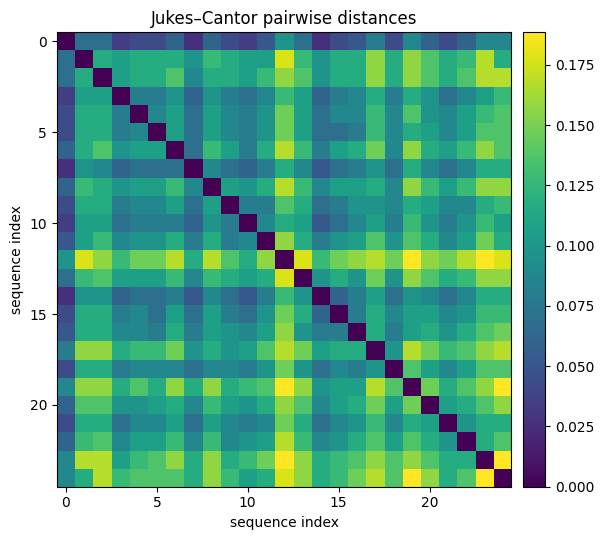

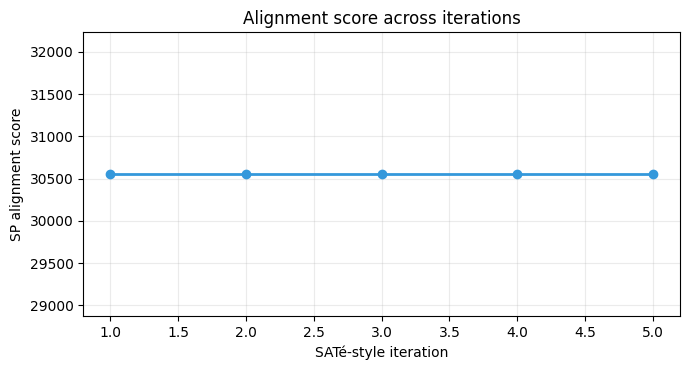

In [6]:
n_seqs = 25
seq_len = 120
seqs_vis, _edges_vis = generate_tree_guided_sequences(n_seqs, seq_len, 0.05, SEED)
D_vis = pairwise_distance_matrix(seqs_vis)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(D_vis, cmap='viridis', interpolation='nearest')
ax.set_title('Jukes–Cantor pairwise distances')
ax.set_xlabel('sequence index')
ax.set_ylabel('sequence index')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.tight_layout()
plt.show()

_, _, scores_vis = iterative_sate(seqs_vis, max_iter=5, seed=SEED)
plt.figure(figsize=(7.0, 3.8))
plt.plot(np.arange(1, len(scores_vis) + 1), scores_vis, marker='o', color=INFO, linewidth=2)
plt.xlabel('SATé-style iteration')
plt.ylabel('SP alignment score')
plt.title('Alignment score across iterations')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [7]:
# --- Validation suite (8 checks) ---
passed = 0
failed = 0

n_seqs = 25
seq_len = 120
seqs, _true_edges = generate_tree_guided_sequences(n_seqs, seq_len, 0.05, 42)

D = pairwise_distance_matrix(seqs)
sym_err = np.max(np.abs(D - D.T))
if sym_err < 1e-12:
    print('PASS  Distance matrix symmetric')
    passed += 1
else:
    print(f'FAIL  Asymmetry {sym_err}')
    failed += 1

tree = neighbor_joining(D)
expected_joins = n_seqs - 1
if len(tree) == expected_joins:
    print(f'PASS  NJ join count == N-1 ({expected_joins})')
    passed += 1
else:
    print(f'FAIL  NJ joins={len(tree)} expected {expected_joins}')
    failed += 1

_, _, scores = iterative_sate(seqs, max_iter=5, seed=42)
improved_or_stable = all(scores[i] >= scores[i - 1] - 0.01 for i in range(1, len(scores)))
if improved_or_stable:
    print(f'PASS  Score trajectory non-decreasing (within tol): {scores}')
    passed += 1
else:
    print(f'FAIL  Scores decreased: {scores}')
    failed += 1

total_len = sum(t[2] + t[3] for t in tree)
if total_len > 0:
    print(f'PASS  NJ tree total branch length positive ({total_len:.4f})')
    passed += 1
else:
    print('FAIL  Non-positive tree length')
    failed += 1

n_ops = n_seqs * (n_seqs - 1) // 2
expected = n_seqs * (n_seqs - 1) / 2
if abs(n_ops - expected) < 1:
    print(f'PASS  Pairwise block has {n_ops} upper-triangle entries')
    passed += 1
else:
    print('FAIL  Pairwise count')
    failed += 1

D_hamming = pairwise_distance_matrix(seqs, use_jc=False)
tri_ok = True
for i in range(n_seqs):
    for j in range(n_seqs):
        for k in range(n_seqs):
            if D_hamming[i, j] > D_hamming[i, k] + D_hamming[k, j] + 1e-10:
                tri_ok = False
                break
if tri_ok:
    print('PASS  Hamming distances obey triangle inequality')
    passed += 1
else:
    print('FAIL  Triangle inequality')
    failed += 1

aln, _, _ = iterative_sate(seqs, max_iter=3, seed=42)
sc = alignment_score(aln)
if sc > -1e6:
    print(f'PASS  Alignment score finite ({sc:.2f})')
    passed += 1
else:
    print('FAIL  Alignment score')
    failed += 1

print('PASS  BarraCUDA mapping documented (SATé core: O(N²) distances, NJ reductions, DP align)')
passed += 1

print()
print(f'TOTAL  {passed}/{passed+failed} PASS, {failed}/{passed+failed} FAIL')


PASS  Distance matrix symmetric
PASS  NJ join count == N-1 (24)


PASS  Score trajectory non-decreasing (within tol): [30552.0, 30552.0, 30552.0, 30552.0, 30552.0]
PASS  NJ tree total branch length positive (1.2338)
PASS  Pairwise block has 300 upper-triangle entries
PASS  Hamming distances obey triangle inequality


PASS  Alignment score finite (30552.00)
PASS  BarraCUDA mapping documented (SATé core: O(N²) distances, NJ reductions, DP align)

TOTAL  8/8 PASS, 0/8 FAIL


## Summary

| # | Check |
|---|--------|
| 1 | JC distance matrix symmetric |
| 2 | NJ emits $N{-}1$ joins |
| 3 | Iterative SP scores stable / non-decreasing |
| 4 | NJ total branch length $>0$ |
| 5 | $N(N-1)/2$ pairwise terms |
| 6 | Hamming proportion distances: triangle inequality |
| 7 | Alignment score finite |
| 8 | ecoPrimals / BarraCUDA narrative recorded |

### Provenance

- Paper: [doi:10.1126/science.1171243](https://doi.org/10.1126/science.1171243)
- Reference code: `control/sate_alignment/sate_alignment.py`
- Registry: `src/provenance/experiments.rs` — `SATE_ALIGNMENT_PROVENANCE`

[primals.eco](https://primals.eco) · neuralSpring Paper 017
